<a href="https://colab.research.google.com/github/CSRobba/Reddit-Post-Scraper/blob/main/process_submissions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Packages

In [ ]:
!pip install --upgrade -q gspread

In [ ]:
import requests
from datetime import datetime, timedelta
from google.auth import default
from google.colab import auth
from google.colab import drive
import gspread
import itertools
import json
import logging
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import nltk
import pandas
import os
import re
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
import time
from tqdm import tqdm
import sys

## Set Default Values

In [ ]:
# Mount Drive
drive.mount('/content/drive')
# TODO: Change this based on Google Drive
WORK_DIR = '/content/drive/My Drive/Research Projects/01 First Author Projects/05 AI Environmental Footprint/04 Online Data Scraping'
RAW_DIR = os.path.join(WORK_DIR, "raw")
PROCESSED_DIR = os.path.join(WORK_DIR, "processed")
QUERIES_FILE = os.path.join(WORK_DIR, "queries_run.csv")
os.chdir(WORK_DIR)

Mounted at /content/drive


In [ ]:
auth.authenticate_user()

In [ ]:
creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
QUERIES = pandas.read_csv(QUERIES_FILE).drop("Unnamed: 0", axis = 1)

# Helper Functions

In [ ]:
def read_json(f):
  with open(os.path.join(RAW_DIR, f), 'r') as file:
    obj = json.load(file)
    return obj

In [ ]:
def check_file_num(files):

  num_files = int(QUERIES[QUERIES["count"] != -1]["count"].sum())
  print(f"NUM FILES (Per Folder): {len(files)}")
  print(f"NUM FILES (Per Queries): {num_files}")

In [ ]:
def clean_raw_names(files):

  for f_old in files:
    if "-" in f_old:
      f_new = f_old.replace("-", "_")
      print(f"Renaming OLD: {f_old} to NEW: {f_new}")
      os.rename(os.path.join(RAW_DIR, f_old), os.path.join(RAW_DIR, f_new))

In [ ]:
def remove_old_queries(files):

  queries = QUERIES[QUERIES["count"] != -1]
  queries_run = [f"{row['ai']} {row['env']}" for _, row in queries.iterrows()]
  queries_run = list(set([q.lower().replace(" ", "_").replace("-", "_") for q in queries_run]))
  file_queries = ["_".join(f.split("_")[1:-3]) for f in files]
  old_queries = list(set([f for f in file_queries if f not in queries_run]))

  print(f"OLD QUERIES: {', '.join(old_queries)}")
  # TODO: Implement deleting old queries

In [ ]:
def check_file_counts(files):

  queries = QUERIES[QUERIES["count"] != -1].copy(deep=True).reset_index(drop = True)

  for _, row in queries.iterrows():
    query_run = f"{row['ai']} {row['env']} {row["start"]}"
    query_file_name = query_run.lower().replace(" ", "_").replace("-", "_") + ".json"
    files_found = [f for f in files if f.endswith(query_file_name)]

    if len(files_found) != int(row["count"]):
      print(f"ERROR: {query_file_name} ROW COUNT ({int(row['count'])}) != NUM FILES ({len(files_found)})")
      queries.at[_, "count"] = -1

  return queries

In [ ]:
def clean_raw():

  for dir, subdirs, files in os.walk(RAW_DIR):
    check_file_num(files)
    clean_raw_names(files)
    remove_old_queries(files)
    queries_to_rerun = check_file_counts(files)

    return queries_to_rerun

In [ ]:
def read_submissions():

  submissions = []
  for dir, subdirs, files in os.walk(RAW_DIR):
    for f in tqdm(files):
      submission = read_json(f)
      submission["filename"] = f
      submissions.append(submission)

  submissions = pandas.DataFrame(submissions)
  submissions["date"] = pandas.to_datetime(submissions["created"])

  return submissions

In [ ]:
def descriptive_analysis(df=QUERIES, desc="Queries (Raw)"):

  submissions = df.copy()
  # Which queries had the most number of posts associated with them?
  num_subs_per_query = submissions.groupby("query_term").agg({"title": "count"}).reset_index().sort_values(by = "title", ascending = False)
  print("Q1) Which queries had the most number of posts associated with them?")
  print(num_subs_per_query.head(n = 10))

  # What time period do we have the most number of posts from?
  submissions["month"] = submissions["date"].dt.month
  submissions["year"] = submissions["date"].dt.year
  num_subs_per_date = submissions.groupby(["month", "year"]).agg({"title": "count"}).reset_index()

  num_subs_per_date = num_subs_per_date.sort_values(by = "title", ascending = False)
  print("Q2) What time period do we have the most number of posts from?")
  print(num_subs_per_date.head(n = 10))

  # What is the average number of comments that each post has?
  print("Q3) What is the average number of comments that each post has?")
  print(submissions["num_comments"].mean())

  # How many post have a removed element (e.g., removed body, user, title)?
  submissions_removed = submissions[(submissions["body"] == "[removed]") | (submissions["body"] == "[deleted]") | (submissions["title"] == "[removed]") | (submissions["title"] == "[deleted]") | (submissions["author"] == "[removed]") | (submissions["author"] == "[deleted]")]
  submissions_removed = submissions_removed.reset_index()
  print("Q4) How many post have a removed element (e.g., removed body, user, title)?")
  print(len(submissions_removed))

  # How many posts have less than five characters in their body?
  submissions_short = submissions[(submissions["body"] != "[removed]") & (submissions["body"] != "[deleted]")  & (submissions["body"].str.len() <= 5)]
  submissions_short = submissions_short.reset_index()
  print("Q5) How many posts have less than five characters in their body?")
  print(len(submissions_short))

  # How many posts just have people posting links with no other text?
  submissions_link = submissions[(submissions["body"] != "[removed]") & (submissions["body"] != "[deleted]") & (submissions["body"].str.len() <= 5) & ~(submissions["url"].str.contains("reddit.com"))]
  submissions_link = submissions_link.reset_index()
  print("Q6) How many posts just have people posting links with no other text?")
  print(len(submissions_link))

  # How many different subreddits are featured in our dataset?
  print("Q7) How many different subreddits are featured in our dataset?")
  print(len(submissions["subreddit"].unique()))

  # What are the most common subreddits that get mentioned?
  num_subs_per_subreddit = submissions.groupby("subreddit").agg({"title": "count"}).reset_index().sort_values(by = "title", ascending = False)
  print("Q8) What are the most common subreddits that get mentioned?")
  print(num_subs_per_subreddit.head(n = 10))

  # How many posts are duplicates (i.e., same title and body, but different subreddit or user)?
  num_subs_dup = submissions.drop_duplicates(subset=["title", "body"])
  print("Q9) How many posts are duplicates (i.e., same title and body, but different subreddit or user)?")
  print(len(submissions) - len(num_subs_dup))

In [ ]:
def process_raw(df = pandas.DataFrame([])):
  if df.empty:
    df = read_submissions()

  print(f"Number of raw submissions: {len(df)}")

  # drop posts that have been removed
  df = df[(df["body"] != "[removed]") & (df["title"] != "[removed]") & (df["author"] != "[removed]") & (df["body"] != "[deleted]") & (df["title"] != "[deleted]") & (df["author"] != "[deleted]")].reset_index(drop = True)
  print(f"Number of submissions (minus those removed): {len(df)}")

  # drop posts that have little content
  df =   df[df["body"].str.len() > 5].reset_index(drop = True)
  print(f"Number of submissions (minus those removed, minus those with short body content): {len(df)}")

  # drop duplicate posts
  df = df.drop_duplicates(subset=["title", "body"])
  print(f"Number of submissions (minus those removed, minus those with short body content, minus duplicates): {len(df)}")

  # drop those with "e-waste" query term
  df = df[~df["query_term"].str.contains("e-waste")].reset_index()
  print(f"Number of submissions (minus those with 'e-waste' keyword): {len(df)}")
  return df

In [ ]:
def save_submissions_clean(df_all):

  worksheet = gc.open('submissions_coding').sheet1
  rows = worksheet.get_all_values()
  worksheet_df = pandas.DataFrame.from_records(rows)

  if worksheet_df.empty:
    worksheet_df = pandas.DataFrame([], columns = df_all.columns)

  df_all = df_all.merge(worksheet_df, how = "left", on = list(df_all.columns))
  df_all = df_all.fillna(" ")
  df_all["date"] = df_all["date"].dt.strftime('%Y-%m-%d')

  df_all = df_all[["date", "id", "query_term", "title", "body", "num_comments",
                   "filename", "subreddit", "author",
                   "url", "url_overridden_by_dest", "created",
                   "ups", "upvote_ratio", "view_count"]]

  df_all = df_all.sample(frac=1).reset_index(drop=True)

  worksheet.update([df_all.columns.values.tolist()] + df_all.values.tolist())

In [ ]:
def submission_clustering(df):

  nltk.download('stopwords')
  stemmer = SnowballStemmer("english")
  stop_words = set(stopwords.words("english"))

  def process_text(t):
    t = re.sub(r'\W+', ' ', t)
    t = re.sub(r'\d+', '', t)
    t = t.lower()
    t = ' '.join([stemmer.stem(word) for word in t.split() if word not in stop_words])
    return t

  df["text"] = df.apply(lambda x:
                        process_text(f"{x['title']} {x['body']}"),
                        axis = 1)

  # Transform the cleaned text data to TF-IDF features
  tfidf_vectorizer = TfidfVectorizer(max_features=5000)
  X_tfidf = tfidf_vectorizer.fit_transform(df['text'])

  # Apply K-Means with a predetermined number of clusters
  num_clusters = 2
  kmeans = KMeans(n_clusters=num_clusters, random_state=42)
  kmeans.fit(X_tfidf)

  # Get the cluster assignments
  labels_kmeans = kmeans.labels_
  df['cluster_kmeans'] = labels_kmeans

  tsne = TSNE(n_components=2, random_state=42)
  X_tsne = tsne.fit_transform(X_tfidf.toarray())

  # Plotting the clusters
  plt.figure(figsize=(8, 6))
  plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_kmeans, cmap='viridis', marker='o', label="Cluster")
  plt.title('t-SNE Visualization of Clusters')
  plt.legend(loc="best")
  plt.show()

  return df

# MAIN

In [ ]:
queries_to_rerun = clean_raw()

NUM FILES (Per Folder): 5966
NUM FILES (Per Queries): 6294
OLD QUERIES: 
ERROR: ai_water_use_2022_12_07.json ROW COUNT (1) != NUM FILES (0)
ERROR: ai_water_use_2022_12_28.json ROW COUNT (1) != NUM FILES (0)
ERROR: ai_water_use_2023_01_11.json ROW COUNT (1) != NUM FILES (0)
ERROR: ai_water_use_2023_01_18.json ROW COUNT (2) != NUM FILES (0)
ERROR: ai_water_use_2023_01_25.json ROW COUNT (2) != NUM FILES (0)
ERROR: ai_water_use_2023_02_08.json ROW COUNT (1) != NUM FILES (0)
ERROR: ai_water_use_2023_02_22.json ROW COUNT (5) != NUM FILES (0)
ERROR: ai_water_use_2023_03_01.json ROW COUNT (3) != NUM FILES (0)
ERROR: ai_water_use_2023_03_08.json ROW COUNT (2) != NUM FILES (1)
ERROR: ai_water_use_2023_03_15.json ROW COUNT (2) != NUM FILES (1)
ERROR: ai_water_use_2023_03_22.json ROW COUNT (3) != NUM FILES (1)
ERROR: ai_water_use_2023_03_29.json ROW COUNT (1) != NUM FILES (0)
ERROR: ai_water_use_2023_04_05.json ROW COUNT (1) != NUM FILES (0)
ERROR: ai_water_use_2023_04_12.json ROW COUNT (10) != NU

In [ ]:
submissions = read_submissions()

100%|██████████| 5966/5966 [02:56<00:00, 33.80it/s] 


In [ ]:
descriptive_analysis(df=submissions, desc="Queries (Raw)")

Q1) Which queries had the most number of posts associated with them?
               query_term  title
13               AI waste   2911
12      AI sustainability    756
4           AI energy use    461
26          ChatGPT waste    309
16           AI water use    291
11           AI pollution    194
1   AI energy consumption    181
0      AI carbon emission     86
9   AI environment impact     61
29      ChatGPT water use     54
Q2) What time period do we have the most number of posts from?
    month  year  title
11      4  2025    519
8       3  2025    423
5       2  2025    327
30     12  2024    315
27     11  2024    284
2       1  2025    271
24     10  2024    252
18      7  2024    237
13      5  2024    205
26     11  2023    196
Q3) What is the average number of comments that each post has?
3.070753906920831
Q4) How many post have a removed element (e.g., removed body, user, title)?
764
Q5) How many posts have less than five characters in their body?
3960
Q6) How many posts ju

In [ ]:
submissions_cleaned = process_raw(df=submissions)

Number of raw submissions: 5823
Number of submissions (minus those removed): 5059
Number of submissions (minus those removed, minus those with short body content): 1111
Number of submissions (minus those removed, minus those with short body content, minus duplicates): 1001
Number of submissions (minus those with 'e-waste' keyword): 1001


In [ ]:
descriptive_analysis(df=submissions_cleaned, desc="Queries (Processed)")

Q1) Which queries had the most number of posts associated with them?
                    query_term  title
11                    AI waste    445
10           AI sustainability    148
23               ChatGPT waste     89
4                AI energy use     60
1        AI energy consumption     39
14                AI water use     37
9                 AI pollution     30
8        AI environment impact     19
26           ChatGPT water use     15
15  ChatGPT energy consumption     11
Q2) What time period do we have the most number of posts from?
    month  year  title
8       3  2025     87
11      4  2025     83
2       1  2025     70
5       2  2025     63
13      5  2024     46
24     10  2024     46
26     11  2024     45
29     12  2024     37
18      7  2024     33
22      9  2024     33
Q3) What is the average number of comments that each post has?
3.6713286713286712
Q4) How many post have a removed element (e.g., removed body, user, title)?
0
Q5) How many posts have less than fiv

In [ ]:
save_submissions_clean(submissions_cleaned)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


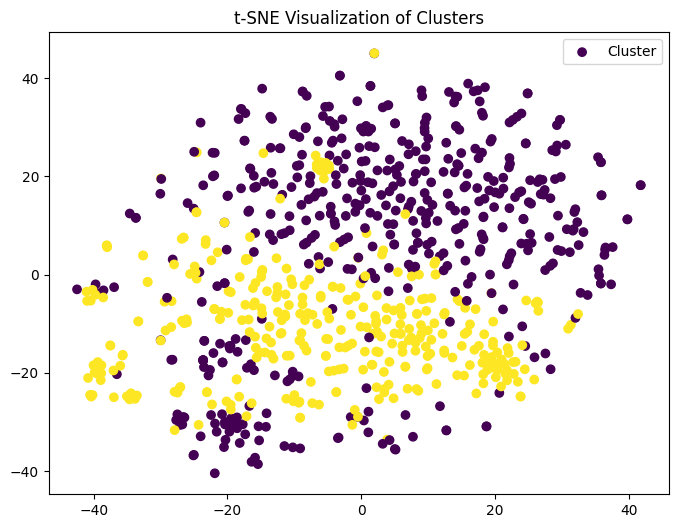

In [ ]:
clusters = submission_clustering(submissions_cleaned)

In [ ]:
clusters_sub = clusters[
    clusters["id"].isin([
    "12epgrf",
    "1k3fibr",
    "19788eu",
    "1ie0r5i",
    "1gqqctn",
    "1jrwi73",
    "1dopuo3",
    "1dw5rbr",
    "1iraktl",
    "18dea6u",
    "1e9l5qc",
    "16xnomv",
    "18oifo9",
    "10ufifd",
    "1cwnbdr",
    "1f9n1zr",
    "10133iy",
    "1jpneuj",
    "184zm3m"]
                        )]

In [ ]:
clusters_sub

,index,query_term,title,id,body,url,url_overridden_by_dest,created,author,subreddit,num_comments,ups,upvote_ratio,view_count,filename,date,text,cluster_kmeans
97,103,AI energy use,The use of AI for improving energy security,1dw5rbr,The authors provide insights into the state of...,https://www.reddit.com/r/energy/comments/1dw5r...,None,2024-07-05T19:07:08,Archaeo-Water18,energy,0,0.0,0.50,None,1dw5rbr_ai_energy_use_2024_07_05.json,2024-07-05 19:07:08,use ai improv energi secur author provid insig...,1
122,128,AI energy use,Use cases Ai in energy supply,1jpneuj,"Hey everyone, I work as a In-house IT consulta...",https://www.reddit.com/r/ElectricalEngineering...,None,2025-04-02T12:32:02,slippy_1993,ElectricalEngineering,0,1.0,1.00,None,1jpneuj_ai_energy_use_2025_04_02.json,2025-04-02 12:32:02,use case ai energi suppli hey everyon work hou...,1
703,777,AI sustainability,What We Can Expect To Happen in the NFT Market...,184zm3m,"As we gear up for 2024, let's strap in for a t...",https://www.reddit.com/r/NFTsMarketplace/comme...,None,2023-11-27T10:07:27,andreagabrie,NFTsMarketplace,0,1.0,1.00,None,184zm3m_ai_sustainability_2023_11_27.json,2023-11-27 10:07:27,expect happen nft market ai vr sustain beyond ...,1
759,839,AI sustainability,"With Apple leaning into AI, and sustainability...",1gqqctn,*Disclaimer*: I'm building a business with my ...,https://www.reddit.com/r/u_josh-afterlife/comm...,None,2024-11-13T23:06:35,josh-afterlife,u_josh-afterlife,6,0.0,0.25,None,1gqqctn_ai_sustainability_2024_11_13.json,2024-11-13 23:06:35,appl lean ai sustain effort fall short done bu...,0
